## Question 7 - *Locality: do tasks from the same job run on the same machine?*

**Metrics.**
We evaluate locality with two complementary indicators:
1. **Machines per job:** `#machines(job)` = number of distinct machines hosting scheduled tasks of the job.  
   A job is “fully local” if `#machines(job)=1`.
2. **Dominant-machine fraction:**  
   `dominant_fraction(job) = max_m (#tasks of job scheduled on m) / #tasks(job)`

**Method (Spark RDD).**
1. Keep only SCHEDULE events with a valid machine_id.
2. Deduplicate by `(job_id, task_index, machine_id)` to handle rescheduling.
3. Compute per job:
   - #distinct tasks
   - #distinct machines
   - dominant_fraction via per (job,machine) task counts
4. Summarize distribution (mean/median/percentiles).

In [1]:
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "./data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "./data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "./data/task_events/*.csv.gz"
PATH_TASK_USAGE = "./data/task_usage/*.csv.gz"

# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

SCHEDULE = 1  # event_type code for SCHEDULE

def parse_task_event_for_locality(line):
    p = line.split(",")
    if len(p) < 6:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or job_id is None or task_index is None or et is None:
        return None
    return (job_id, task_index, machine_id, et, ts)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/14 23:16:01 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
26/01/14 23:16:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/14 23:16:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# ----------------------------
# Load + filter schedule events
# ----------------------------
task_events_raw = sc.textFile(PATH_TASK_EVENTS)
task_events_parsed = task_events_raw.map(parse_task_event_for_locality).filter(lambda x: x is not None)

scheduled = (
    task_events_parsed
    .filter(lambda x: x[3] == SCHEDULE and x[2] is not None)
    .map(lambda x: (x[0], x[1], x[2], x[4]))  # (job_id, task_index, machine_id, timestamp)
    .cache()
)

In [3]:
# ----------------------------
# Use ALL schedule events
# ----------------------------
job_task_machine = scheduled.map(lambda x: ((x[0], x[1], x[2]), 1)).distinct().map(lambda x: x[0]).cache()

# ----------------------------
# Metric 1: #machines(job) and nb_tasks(job)
# ----------------------------
machines_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[2]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb distinct_machines)
)

tasks_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb distinct_tasks_scheduled)
)

job_counts = tasks_per_job.join(machines_per_job)
# (job, (nb tasks, nb machines))

# Summary stats
num_jobs = job_counts.count()
jobs_one_machine = job_counts.filter(lambda x: x[1][1] == 1).count()
avg_machines = job_counts.map(lambda x: x[1][1]).mean()

print("Jobs analyzed:", num_jobs)
print("Jobs with all scheduled tasks on 1 machine:", jobs_one_machine, f"({100*jobs_one_machine/num_jobs:.2f}%)")
print("Average #distinct machines per job:", avg_machines)

# Distribution of number of machines
machines_dist = (
    job_counts
    .map(lambda x: (x[1][1], 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
machines_dist = sorted(machines_dist, key=lambda x: x[0])
print("\nDistribution (#machines -> #jobs):")
for m, c in machines_dist[:20]:
    print(m, c)
if len(machines_dist) > 20:
    print("...")

26/01/14 23:16:10 WARN BlockManager: Block rdd_7_4 already exists on this machine; not re-adding it
26/01/14 23:16:10 WARN BlockManager: Block rdd_7_1 already exists on this machine; not re-adding it
26/01/14 23:16:10 WARN BlockManager: Block rdd_7_3 already exists on this machine; not re-adding it


Jobs analyzed: 7008
Jobs with all scheduled tasks on 1 machine: 4988 (71.18%)
Average #distinct machines per job: 30.891267123287665

Distribution (#machines -> #jobs):
1 4988
2 437
3 125
4 93
5 57
6 31
7 27
8 20
9 61
10 21
11 42
12 32
13 4
14 45
15 182
16 26
17 3
18 11
19 3
20 17
...


In [4]:
# ----------------------------
# Metric 2: dominant fraction per job
# dominant_fraction = max_{machine} (nb tasks scheduled on machine) / (nb tasks scheduled in job)
# ----------------------------
tasks_per_job_machine = (
    job_task_machine
    .map(lambda x: ((x[0], x[2]), x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)          # ((job, machine), #tasks_on_machine)
)

# For each job: get max tasks_on_machine
max_tasks_on_one_machine = (
    tasks_per_job_machine
    .map(lambda x: (x[0][0], x[1])) 
    .reduceByKey(lambda a,b: a if a>b else b)  # (job, max_tasks_on_machine)
)

dominant_fraction = (
    tasks_per_job.join(max_tasks_on_one_machine)
    .mapValues(lambda x: x[1] / x[0] if x[0] > 0 else 0.0)
    .cache()
)

avg_dom_frac = dominant_fraction.map(lambda x: x[1]).mean()
print("\nAverage dominant-machine fraction:", avg_dom_frac)

# Distribution of dominant fraction (bucketed)
def frac_bucket(f):
    # buckets of 0.1
    b = int(min(0.999, f) * 10)
    lo = b / 10
    hi = lo + 0.1
    return f"[{lo:.1f},{hi:.1f})"

dom_dist = (
    dominant_fraction
    .map(lambda x: (frac_bucket(x[1]), 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
# sort by bucket lower bound
def bucket_key(lbl):
    return float(lbl[1:4])
dom_dist = sorted(dom_dist, key=lambda x: bucket_key(x[0]))

print("\nDominant fraction distribution (bucket -> #jobs):")
for b, c in dom_dist:
    print(b, c)


Average dominant-machine fraction: 0.7853121890190708

Dominant fraction distribution (bucket -> #jobs):
[0.0,0.1) 1102
[0.1,0.2) 133
[0.2,0.3) 119
[0.3,0.4) 91
[0.4,0.5) 5
[0.5,0.6) 341
[0.6,0.7) 2
[0.9,1.0) 5215


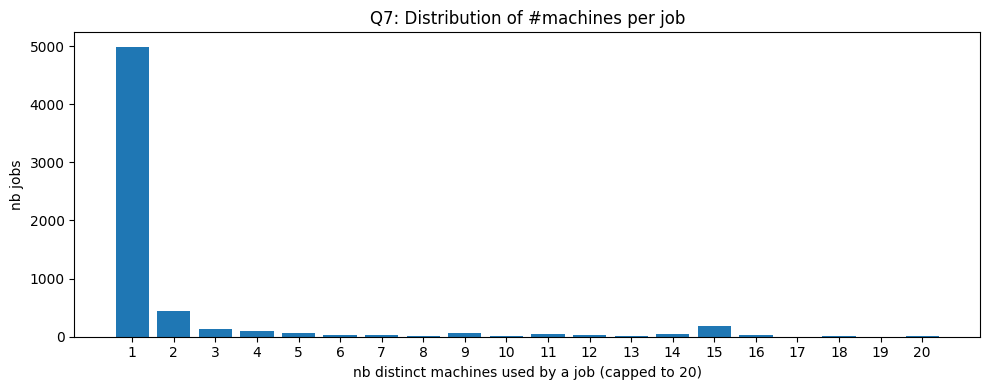

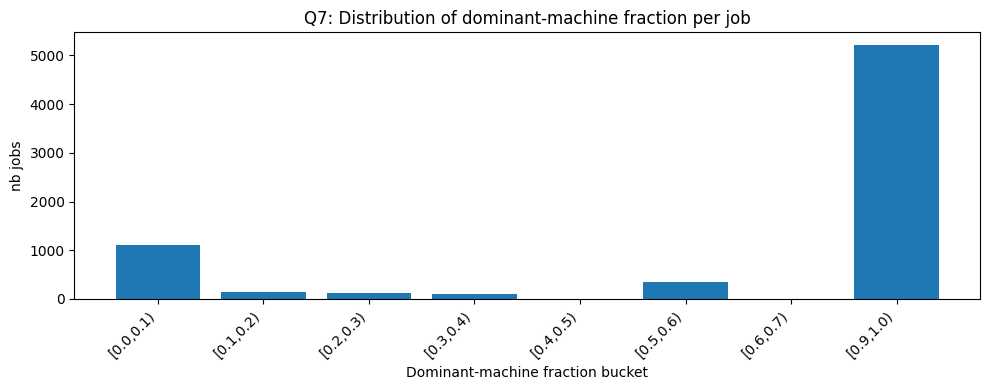

In [5]:
# Plot distribution of nb machines per job
xs = [m for m, _ in machines_dist if m <= 20]
ys = [c for m, c in machines_dist if m <= 20]

plt.figure(figsize=(10,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("nb distinct machines used by a job (capped to 20)")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of #machines per job")
plt.tight_layout()
# plt.savefig("../figures/q7_machines_per_job_dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot dominant fraction distribution
bx = [b for b, _ in dom_dist]
by = [c for _, c in dom_dist]

plt.figure(figsize=(10,4))
plt.bar(bx, by)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant-machine fraction bucket")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of dominant-machine fraction per job")
plt.tight_layout()
# plt.savefig("../figures/q7_dominant_fraction_dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# machines per job values
machines_vals = job_counts.map(lambda x: x[1][1]).cache()

# Median via approx quantiles
vals_sorted = machines_vals.sortBy(lambda x: x).zipWithIndex().map(lambda x: (x[1], x[0]))
n = machines_vals.count()

median = vals_sorted.lookup(n//2)[0] if n > 0 else None
p90 = vals_sorted.lookup(int(0.90*n))[0] if n > 0 else None
p99 = vals_sorted.lookup(int(0.99*n))[0] if n > 0 else None

jobs_gt_20 = machines_vals.filter(lambda m: m > 20).count()
print("Median nb_machines/job:", median)
print("90th percentile:", p90)
print("99th percentile:", p99)
print("Jobs using >20 machines:", jobs_gt_20, f"({100*jobs_gt_20/n:.2f}%)")

Median nb_machines/job: 1
90th percentile: 23
99th percentile: 619
Jobs using >20 machines: 783 (11.17%)


**Results (subset).**
Jobs analyzed: **7,008**
- Jobs with `#machines=1`: **4,988 (71.18%)**
- Mean `#machines/job`: **30.89**
- Median `#machines/job`: **1**
- 90th percentile: **23**
- 99th percentile: **619**
- Jobs using >20 machines: **783 (11.17%)**
- Avg dominant_fraction: **0.785**
- Many jobs fall into dominant_fraction bucket **[0.9,1.0)** (high concentration on one machine).

**Interpretation.**
- Most jobs show strong locality: median = 1 machine and ~71% of jobs stay on a single machine.
- However, placement is heavy-tailed: a minority of jobs spreads over many machines (up to hundreds), which inflates the mean.
- This matches a strategy where small jobs are kept local, while larger jobs are distributed for parallelism.